In [1]:
!nvidia-smi

Thu Apr 23 06:27:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [5]:

from roboflow import Roboflow
rf = Roboflow(api_key="U0Xl13KthIp9Z6LgeYym")
project = rf.workspace("farrel-0mplf").project("pahlawan-indonesia")
version = project.version(4)
dataset = version.download("yolov9")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pahlawan-indonesia-4 in yolov9:: 100%|██████████| 1241/1241 [00:00<00:00, 5302.64it/s]


In [6]:
# Ultralytics
from ultralytics import YOLO
model = YOLO("yolov9c.pt")
model.info()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv9c summary: 358 layers, 25,590,912 parameters, 0 gradients, 104.0 GFLOPs


(358, 25590912, 0, 104.02268160000003)

In [7]:
model.train(
    data="/content/pahlawan-indonesia-4/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pahlawan-indonesia-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac1d3503980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0

In [8]:
import yaml

with open('/content/pahlawan-indonesia-4/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

if 'names' in data:
    print("Classes:", data['names'])
else:
    print("Class names not found in the YAML file.")

Classes: ['A.I.P. II Karel Satsuit Tubun', 'B.J. Habibie', 'Brigjen Katamso Darmokusumo', 'Cut Meutia', 'Cut Nyak Dien', 'Douwes Dekker', 'Dr. Cipto Mangunkusumo', 'Dr. Muwardi', 'Dr. Soetomo', 'Dr. Wahidin Soedirohusodo', 'HOS Tjokroaminoto', 'Jenderal Ahmad Yani', 'Jendral Sudirman', 'Kapitan Pattimura', 'Kapten Pierre Tendean', 'Ki Hajar Dewantara', 'Kolonel Sugiyono Mangunwiyoto', 'Laksamana Malahayati', 'Letjen MT Haryono', 'Letjen R. Suprapto', 'Letjen S. Parman', 'Mayjen DI Panjaitan', 'Mayjen Sutoyo Siswomiharjo', 'Mohammad Hatta', 'Pangeran Diponegoro', 'R.A. Kartini', 'Sisingamangaraja', 'Soekarno']



image 1/1 /content/sample.jpeg: 640x544 1 Soekarno, 65.6ms
Speed: 2.6ms preprocess, 65.6ms inference, 6.6ms postprocess per image at shape (1, 3, 640, 544)


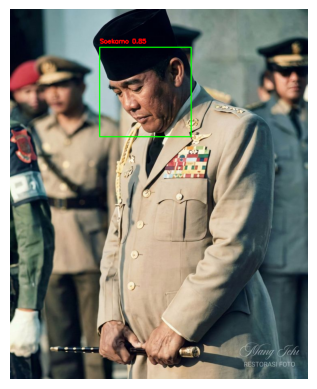

In [14]:
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Load model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Load image
image_path = '/content/sample.jpeg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Run prediction
results = model(image_path)

# Draw all detected boxes
for box in results[0].boxes:
    cls_id = int(box.cls.item())
    conf = float(box.conf.item())
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    label = f"{model.names[cls_id]} {conf:.2f}"

    # Draw box + label
    cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(image, label, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

# Show result
plt.imshow(image)
plt.axis('off')
plt.show()


In [15]:
import json
# results = model(image_path)

# You can optionally filter by confidence threshold
CONF_THRESHOLD = 0.3  # ignore detections with conf < 0.3

# Collect detection results
detections = []
for box in results[0].boxes:
    cls_id = int(box.cls.item())
    conf = float(box.conf.item())

    # Skip low confidence results
    if conf < CONF_THRESHOLD:
        continue

    class_name = model.names[cls_id]
    x1, y1, x2, y2 = map(float, box.xyxy[0].tolist())

    detections.append({
        "class_id": cls_id,
        "class_name": class_name,
        "confidence": round(conf, 4),
        "coordinates": {
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2
        }
    })

# Convert results to JSON
json_result = json.dumps(detections, indent=4, ensure_ascii=False)

# Print JSON result (pretty format)
print(json_result)

# If you want to save it to file:
# with open('/content/detections.json', 'w') as f:
#     f.write(json_result)


[
    {
        "class_id": 27,
        "class_name": "Soekarno",
        "confidence": 0.8511,
        "coordinates": {
            "x1": 221.82688903808594,
            "y1": 94.04027557373047,
            "x2": 447.9169006347656,
            "y2": 315.32373046875
        }
    }
]


In [18]:
history = [
  {
    "nama": "Cut Meutia",
    "kategori": "Pahlawan Kemerdekaan Nasional",
    "cerita": "Cut Meutia adalah pahlawan wanita dari Aceh yang berjuang melawan penjajahan Belanda dan gugur dalam pertempuran pada tahun 1910."
  },
  {
    "nama": "Sisingamangaraja",
    "kategori": "Pahlawan Kemerdekaan Nasional",
    "cerita": "Sisingamangaraja adalah raja Batak yang memimpin perlawanan terhadap Belanda di Sumatera Utara hingga gugur pada tahun 1907."
  },
  {
    "nama": "Dr. Muwardi",
    "kategori": "Pahlawan Kemerdekaan Nasional",
    "cerita": "Dr. Muwardi adalah tokoh pejuang kemerdekaan yang berperan dalam menjaga keamanan saat proklamasi Indonesia."
  },

  {
    "nama": "Jenderal Ahmad Yani",
    "kategori": "Pahlawan Revolusi",
    "cerita": "Jenderal Ahmad Yani adalah Panglima Angkatan Darat yang gugur dalam peristiwa G30S 1965."
  },
  {
    "nama": "Letjen R. Suprapto",
    "kategori": "Pahlawan Revolusi",
    "cerita": "Letjen R. Suprapto adalah perwira tinggi TNI yang gugur dalam peristiwa G30S 1965."
  },
  {
    "nama": "Letjen MT Haryono",
    "kategori": "Pahlawan Revolusi",
    "cerita": "Letjen MT Haryono adalah perwira TNI yang gugur dalam peristiwa G30S 1965."
  },
  {
    "nama": "Letjen S. Parman",
    "kategori": "Pahlawan Revolusi",
    "cerita": "Letjen S. Parman adalah perwira intelijen TNI yang gugur dalam peristiwa G30S 1965."
  },
  {
    "nama": "Mayjen DI Panjaitan",
    "kategori": "Pahlawan Revolusi",
    "cerita": "Mayjen DI Panjaitan adalah perwira TNI yang gugur dalam peristiwa G30S 1965."
  },
  {
    "nama": "Mayjen Sutoyo Siswomiharjo",
    "kategori": "Pahlawan Revolusi",
    "cerita": "Mayjen Sutoyo Siswomiharjo adalah perwira TNI yang gugur dalam peristiwa G30S 1965."
  },
  {
    "nama": "Brigjen Katamso Darmokusumo",
    "kategori": "Pahlawan Revolusi",
    "cerita": "Brigjen Katamso Darmokusumo adalah komandan TNI yang gugur dalam peristiwa G30S 1965 di Yogyakarta."
  },
  {
    "nama": "Kolonel Sugiyono Mangunwiyoto",
    "kategori": "Pahlawan Revolusi",
    "cerita": "Kolonel Sugiyono Mangunwiyoto adalah perwira TNI yang gugur dalam peristiwa G30S 1965."
  },
  {
    "nama": "Kapten Pierre Tendean",
    "kategori": "Pahlawan Revolusi",
    "cerita": "Kapten Pierre Tendean adalah ajudan Ahmad Yani yang gugur dalam peristiwa G30S 1965."
  },
  {
    "nama": "A.I.P. II Karel Satsuit Tubun",
    "kategori": "Pahlawan Revolusi",
    "cerita": "A.I.P. II Karel Satsuit Tubun adalah anggota polisi yang gugur saat menjalankan tugas dalam peristiwa G30S 1965."
  },

  {
    "nama": "Soekarno",
    "kategori": "Pahlawan Proklamator",
    "cerita": "Soekarno adalah proklamator kemerdekaan Indonesia dan Presiden pertama Indonesia."
  },
  {
    "nama": "Mohammad Hatta",
    "kategori": "Pahlawan Proklamator",
    "cerita": "Mohammad Hatta adalah proklamator kemerdekaan Indonesia dan Wakil Presiden pertama Indonesia."
  },

  {
    "nama": "Kapitan Pattimura",
    "kategori": "Pahlawan Perintis Kemerdekaan",
    "cerita": "Kapitan Pattimura memimpin perlawanan rakyat Maluku terhadap Belanda pada tahun 1817."
  },
  {
    "nama": "Laksamana Malahayati",
    "kategori": "Pahlawan Perintis Kemerdekaan",
    "cerita": "Laksamana Malahayati adalah laksamana wanita pertama yang memimpin armada laut Aceh melawan Belanda."
  },
  {
    "nama": "Cut Nyak Dien",
    "kategori": "Pahlawan Perintis Kemerdekaan",
    "cerita": "Cut Nyak Dien adalah pahlawan wanita Aceh yang berjuang melawan penjajahan Belanda."
  },
  {
    "nama": "Pangeran Diponegoro",
    "kategori": "Pahlawan Perintis Kemerdekaan",
    "cerita": "Pangeran Diponegoro memimpin Perang Jawa melawan Belanda pada 1825–1830."
  },

  {
    "nama": "Dr. Wahidin Soedirohusodo",
    "kategori": "Pahlawan Kebangkitan Nasional",
    "cerita": "Dr. Wahidin Soedirohusodo adalah pelopor kebangkitan nasional Indonesia."
  },
  {
    "nama": "Dr. Soetomo",
    "kategori": "Pahlawan Kebangkitan Nasional",
    "cerita": "Dr. Soetomo adalah pendiri Budi Utomo yang berperan dalam kebangkitan nasional."
  },
  {
    "nama": "Douwes Dekker",
    "kategori": "Pahlawan Kebangkitan Nasional",
    "cerita": "Douwes Dekker adalah tokoh pergerakan nasional yang memperjuangkan kemerdekaan Indonesia."
  },
  {
    "nama": "Dr. Cipto Mangunkusumo",
    "kategori": "Pahlawan Kebangkitan Nasional",
    "cerita": "Dr. Cipto Mangunkusumo adalah tokoh pergerakan nasional yang aktif melawan penjajahan."
  },
  {
    "nama": "Ki Hajar Dewantara",
    "kategori": "Pahlawan Kebangkitan Nasional",
    "cerita": "Ki Hajar Dewantara adalah pelopor pendidikan nasional Indonesia."
  },
  {
    "nama": "HOS Tjokroaminoto",
    "kategori": "Pahlawan Kebangkitan Nasional",
    "cerita": "HOS Tjokroaminoto adalah pemimpin Sarekat Islam yang berperan dalam pergerakan nasional."
  },

  {
    "nama": "R.A. Kartini",
    "kategori": "Pahlawan Nasional",
    "cerita": "R.A. Kartini adalah pelopor emansipasi wanita Indonesia."
  },
  {
    "nama": "Jendral Sudirman",
    "kategori": "Pahlawan Nasional",
    "cerita": "Jendral Sudirman adalah panglima besar TNI yang memimpin perang gerilya."
  },
  {
    "nama": "B.J. Habibie",
    "kategori": "Pahlawan Nasional",
    "cerita": "B.J. Habibie adalah Presiden ke-3 Indonesia dan tokoh penting dalam teknologi nasional."
  }
]

In [19]:
if detections:
    detected_hero_name = detections[0]['class_name']

    for hero in history:
        # Case-insensitive + strip biar lebih aman
        if hero['nama'].lower().strip() == detected_hero_name.lower().strip():
            print(f"\n=== DATA PAHLAWAN ===")
            print(f"Nama     : {hero['nama']}")
            print(f"Kategori : {hero['kategori']}")
            print(f"Cerita   : {hero['cerita']}")
            break
    else:
        print("Pahlawan tidak ditemukan di database.")
else:
    print("No hero detected or confidence too low.")


=== DATA PAHLAWAN ===
Nama     : Soekarno
Kategori : Pahlawan Proklamator
Cerita   : Soekarno adalah proklamator kemerdekaan Indonesia dan Presiden pertama Indonesia.


In [21]:
!zip -r farrel-runs.zip runs/

updating: runs/ (stored 0%)
updating: runs/detect/ (stored 0%)
updating: runs/detect/train/ (stored 0%)
updating: runs/detect/train/labels.jpg (deflated 20%)
updating: runs/detect/train/train_batch2520.jpg (deflated 11%)
updating: runs/detect/train/BoxPR_curve.png (deflated 19%)
updating: runs/detect/train/confusion_matrix.png (deflated 15%)
updating: runs/detect/train/val_batch2_pred.jpg (deflated 8%)
updating: runs/detect/train/BoxF1_curve.png (deflated 9%)
updating: runs/detect/train/confusion_matrix_normalized.png (deflated 12%)
updating: runs/detect/train/val_batch0_labels.jpg (deflated 12%)
updating: runs/detect/train/results.png (deflated 7%)
updating: runs/detect/train/train_batch0.jpg (deflated 6%)
updating: runs/detect/train/val_batch0_pred.jpg (deflated 11%)
updating: runs/detect/train/val_batch2_labels.jpg (deflated 8%)
updating: runs/detect/train/results.csv (deflated 62%)
updating: runs/detect/train/weights/ (stored 0%)
updating: runs/detect/train/weights/last.pt (deflate